# Lab 3: Multi-Source Retail Sales Data Integration and Analysis

**Platform:** R / Google Colab  
**Dataset:** UCI Online Retail Dataset  
**Goal:** Import CSV + JSON + Excel, clean and integrate them, perform sales/customer analysis, store the result in SQLite, run SQL queries, and report business insights.


In [1]:
# Install required R packages
install.packages(
  c("tidyverse", "readxl", "jsonlite", "DBI", "RSQLite", "lubridate"),
  repos = "https://cloud.r-project.org"
)

library(tidyverse)
library(readxl)
library(jsonlite)
library(DBI)
library(RSQLite)
library(lubridate)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




## Step 0 — Upload the supplied Excel file

The assignment asks for CSV, JSON and Excel inputs. Since the supplied file is one `Online Retail.xlsx`, we first split it into the three required source files using R itself.


In [4]:
### Upload the `Online Retail.xlsx` file

Please upload the `Online Retail.xlsx` file manually using the files icon on the left sidebar of Colab. Once uploaded, right-click on the file in the file browser, select 'Copy path', and paste it into the prompt in the next code cell.

ERROR: Error in parse(text = input): <text>:3:8: unexpected symbol
2: 
3: Please upload
          ^


In [5]:
# Set the path returned by file.choose()
# Example:
master_path <- "/content/Online Retail.xlsx"

master_path <- readline("Enter the uploaded Online Retail.xlsx path: ")

retail_raw <- read_excel(master_path)

cat("Rows:", nrow(retail_raw), "\n")
cat("Columns:", ncol(retail_raw), "\n")
print(names(retail_raw))
head(retail_raw)


Enter the uploaded Online Retail.xlsx path: /content/Online Retail.xlsx
Rows: 541909 
Columns: 8 
[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"    


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


In [12]:
# Create the three heterogeneous source files required by the assignment

dir.create("/content/retail_sources", showWarnings = FALSE)

transactions <- retail_raw %>%
  select(InvoiceNo, StockCode, CustomerID, Quantity, InvoiceDate)

products <- retail_raw %>%
  select(StockCode, Description, UnitPrice) %>%
  filter(!is.na(StockCode)) %>%
  arrange(StockCode, UnitPrice) %>%
  distinct(StockCode, .keep_all = TRUE)

customers <- retail_raw %>%
  select(CustomerID, Country) %>%
  filter(!is.na(CustomerID)) %>%
  distinct(CustomerID, .keep_all = TRUE) # Added .keep_all = TRUE to retain Country column

write_csv(transactions, "/content/retail_sources/transactions.csv")
write_json(products, "/content/retail_sources/products.json", pretty = TRUE, na = "null")
write_xlsx <- function(data, path) {
  # writexl is installed only for this small export step
  if (!requireNamespace("writexl", quietly = TRUE)) {
    install.packages("writexl", repos = "https://cloud.r-project.org")
  }
  writexl::write_xlsx(data, path)
}
write_xlsx(customers, "/content/retail_sources/customers.xlsx")

cat("Source files created in /content/retail_sources/\n")
list.files("/content/retail_sources")

Source files created in /content/retail_sources/


[1] "customers.xlsx"   "products.json"    "transactions.csv"

## Task 1 — Import and Clean the Data

In [14]:
# Import CSV, JSON and Excel separately

transactions_raw <- read_csv("/content/retail_sources/transactions.csv", show_col_types = FALSE)
products_raw <- fromJSON("/content/retail_sources/products.json")
customers_raw <- read_excel("/content/retail_sources/customers.xlsx")

cat("Transactions:", nrow(transactions_raw), "rows\n")
cat("Products:", nrow(products_raw), "rows\n")
cat("Customers:", nrow(customers_raw), "rows\n")

glimpse(transactions_raw)
glimpse(products_raw)
glimpse(customers_raw)

Transactions: 541909 rows
Products: 4070 rows
Customers: 4372 rows
Rows: 541,909
Columns: 5
$ InvoiceNo   <chr> "536365", "536365", "536365", "536365", "536365", "536365"…
$ StockCode   <chr> "85123A", "71053", "84406B", "84029G", "84029E", "22752", …
$ CustomerID  <dbl> 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17…
$ Quantity    <dbl> 6, 6, 8, 6, 6, 2, 6, 6, 6, 32, 6, 6, 8, 6, 6, 3, 2, 3, 3, …
$ InvoiceDate <dttm> 2010-12-01 08:26:00, 2010-12-01 08:26:00, 2010-12-01 08:2…
Rows: 4,070
Columns: 3
$ StockCode   <chr> "10002", "10080", "10120", "10123C", "10123G", "10124A", "…
$ Description <chr> NA, NA, "DOGGY RUBBER", NA, NA, "SPOTS ON RED BOOKCOVER TA…
$ UnitPrice   <dbl> 0.00, 0.00, 0.21, 0.00, 0.00, 0.42, 0.42, 0.42, 0.00, 0.00…
Rows: 4,372
Columns: 2
$ CustomerID <dbl> 17850, 13047, 12583, 13748, 15100, 15291, 14688, 17809, 153…
$ Country    <chr> "United Kingdom", "United Kingdom", "France", "United Kingd…


In [8]:
# Inspect missing values

missing_summary <- function(data) {
  tibble(
    Column = names(data),
    Missing = sapply(data, function(x) sum(is.na(x))),
    Missing_Percent = round(sapply(data, function(x) mean(is.na(x)) * 100), 2)
  )
}

cat("Transactions missing values:\n")
print(missing_summary(transactions_raw))

cat("\nProducts missing values:\n")
print(missing_summary(products_raw))

cat("\nCustomers missing values:\n")
print(missing_summary(customers_raw))


Transactions missing values:
# A tibble: 5 × 3
  Column      Missing Missing_Percent
  <chr>         <int>           <dbl>
1 InvoiceNo         0             0  
2 StockCode         0             0  
3 CustomerID   135080            24.9
4 Quantity          0             0  
5 InvoiceDate       0             0  

Products missing values:
# A tibble: 3 × 3
  Column      Missing Missing_Percent
  <chr>         <int>           <dbl>
1 StockCode         0             0  
2 Description     847            20.8
3 UnitPrice         0             0  

Customers missing values:
# A tibble: 1 × 3
  Column     Missing Missing_Percent
  <chr>        <int>           <dbl>
1 CustomerID       0               0


In [9]:
# Check duplicates and invalid values

cat("Exact duplicate transaction rows:", sum(duplicated(transactions_raw)), "\n")
cat("Zero/negative quantities:", sum(transactions_raw$Quantity <= 0, na.rm = TRUE), "\n")
cat("Zero/negative unit prices:", sum(transactions_raw$UnitPrice <= 0, na.rm = TRUE), "\n")
cat("Missing CustomerID:", sum(is.na(transactions_raw$CustomerID)), "\n")
cat("Missing StockCode:", sum(is.na(transactions_raw$StockCode)), "\n")


Exact duplicate transaction rows: 5429 
Zero/negative quantities: 10624 


Warning message:
“Unknown or uninitialised column: `UnitPrice`.”


Zero/negative unit prices: 0 
Missing CustomerID: 135080 
Missing StockCode: 0 


In [15]:
products_clean <- products_raw %>%
  as_tibble() %>%
  filter(!is.na(StockCode), !is.na(UnitPrice), UnitPrice > 0) %>%
  mutate(StockCode = as.character(StockCode)) %>%
  distinct(StockCode, .keep_all = TRUE)

# Clean transactions
# Decisions:
# 1. Remove exact duplicate rows.
# 2. Remove rows with missing InvoiceNo/StockCode.
# 3. Remove rows with missing CustomerID because customer-level analysis is required.
# 4. Keep only Quantity > 0 and UnitPrice > 0.
# 5. Create Revenue = Quantity * UnitPrice.

transactions_clean <- transactions_raw %>%
  left_join(products_clean %>% select(StockCode, UnitPrice), by = "StockCode") %>%
  distinct() %>%
  filter(
    !is.na(InvoiceNo),
    !is.na(StockCode),
    !is.na(CustomerID),
    Quantity > 0,
    UnitPrice > 0
  ) %>%
  mutate(
    CustomerID = as.character(CustomerID),
    InvoiceNo = as.character(InvoiceNo),
    StockCode = as.character(StockCode),
    Revenue = Quantity * UnitPrice
  )

# Clean customers
customers_clean <- customers_raw %>%
  mutate(CustomerID = as.character(CustomerID)) %>%
  filter(!is.na(CustomerID), !is.na(Country)) %>%
  distinct(CustomerID, .keep_all = TRUE)

cat("Clean transactions:", nrow(transactions_clean), "\n")
cat("Clean products:", nrow(products_clean), "\n")
cat("Clean customers:", nrow(customers_clean), "\n")

head(transactions_clean)

Clean transactions: 260297 
Clean products: 2650 
Clean customers: 4372 


InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,UnitPrice,Revenue
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>
536365,71053,17850,6,2010-12-01 08:26:00,3.39,20.34
536365,22752,17850,2,2010-12-01 08:26:00,3.95,7.90
536365,21730,17850,6,2010-12-01 08:26:00,4.25,25.50
536367,22745,13047,6,2010-12-01 08:34:00,1.85,11.10
536367,22748,13047,6,2010-12-01 08:34:00,1.85,11.10
536367,22749,13047,8,2010-12-01 08:34:00,3.39,27.12


### Cleaning decisions

- Exact duplicate records are removed.
- Transactions with missing customer IDs are removed because customer-value analysis is required.
- Transactions with zero/negative quantity or unit price are removed as invalid sales records.
- Missing product/customer lookup records are removed from the corresponding lookup tables.
- `Revenue` is calculated as `Quantity × UnitPrice`.

## Task 2 — Integrate the Multiple Data Sources

In [16]:
# Use left_join so every cleaned transaction remains in the final dataset.
# Products and customers are lookup/reference tables.

integrated_data <- transactions_clean %>%
  left_join(
    products_clean %>% select(StockCode, Description),
    by = "StockCode"
  ) %>%
  left_join(
    customers_clean,
    by = "CustomerID"
  )

cat("Final dimensions:", nrow(integrated_data), "rows x", ncol(integrated_data), "columns\n")
glimpse(integrated_data)

Final dimensions: 260297 rows x 9 columns
Rows: 260,297
Columns: 9
$ InvoiceNo   <chr> "536365", "536365", "536365", "536367", "536367", "536367"…
$ StockCode   <chr> "71053", "22752", "21730", "22745", "22748", "22749", "223…
$ CustomerID  <chr> "17850", "17850", "17850", "13047", "13047", "13047", "130…
$ Quantity    <dbl> 6, 2, 6, 6, 6, 8, 6, 2, 3, 3, 4, 3, 3, 3, 3, 24, 24, 12, 2…
$ InvoiceDate <dttm> 2010-12-01 08:26:00, 2010-12-01 08:26:00, 2010-12-01 08:2…
$ UnitPrice   <dbl> 3.39, 3.95, 4.25, 1.85, 1.85, 3.39, 1.45, 8.50, 5.45, 5.45…
$ Revenue     <dbl> 20.34, 7.90, 25.50, 11.10, 11.10, 27.12, 8.70, 17.00, 16.3…
$ Description <chr> "WHITE METAL LANTERN", "SET 7 BABUSHKA NESTING BOXES", "GL…
$ Country     <chr> "United Kingdom", "United Kingdom", "United Kingdom", "Uni…


In [17]:
# Identify unmatched records after joins

unmatched_products <- transactions_clean %>%
  anti_join(products_clean, by = "StockCode")

unmatched_customers <- transactions_clean %>%
  anti_join(customers_clean, by = "CustomerID")

cat("Transactions with unmatched products:", nrow(unmatched_products), "\n")
cat("Transactions with unmatched customers:", nrow(unmatched_customers), "\n")

if (nrow(unmatched_products) > 0) {
  print(head(unmatched_products))
}

if (nrow(unmatched_customers) > 0) {
  print(head(unmatched_customers))
}


Transactions with unmatched products: 0 
Transactions with unmatched customers: 0 


### Join justification

`left_join()` is appropriate because the transaction table is the fact table and every valid transaction should be retained even if a lookup record is missing. `anti_join()` is then used to explicitly identify unmatched product or customer records.

## Task 3 — Sales and Customer Analysis

In [18]:
# 1. Total sales revenue

total_revenue <- integrated_data %>%
  summarise(Total_Revenue = sum(Revenue, na.rm = TRUE))

print(total_revenue)


# A tibble: 1 × 1
  Total_Revenue
          <dbl>
1      4513871.


In [19]:
# 2. Top 5 products based on revenue

top5_products <- integrated_data %>%
  group_by(StockCode, Description) %>%
  summarise(
    Revenue = sum(Revenue, na.rm = TRUE),
    Quantity = sum(Quantity, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(Revenue)) %>%
  slice_head(n = 5)

print(top5_products)


# A tibble: 5 × 4
  StockCode Description                    Revenue Quantity
  <chr>     <chr>                            <dbl>    <dbl>
1 23843     PAPER CRAFT , LITTLE BIRDIE    168470.    80995
2 23166     MEDIUM CERAMIC TOP STORAGE JAR  81033.    77916
3 22086     PAPER CHAIN KIT 50'S CHRISTMAS  39757.    15591
4 22197     SMALL POPCORN HOLDER            35395.    49160
5 22386     JUMBO BAG PINK POLKADOT         33244.    20148


In [20]:
# 3. Top 5 countries based on revenue

top5_countries <- integrated_data %>%
  group_by(Country) %>%
  summarise(
    Revenue = sum(Revenue, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(Revenue)) %>%
  slice_head(n = 5)

print(top5_countries)


# A tibble: 5 × 2
  Country         Revenue
  <chr>             <dbl>
1 United Kingdom 3672778.
2 Netherlands     189665.
3 EIRE            132418.
4 Germany         110760.
5 France           99593.


In [21]:
# 4. Top 5 customers based on total purchase value

top5_customers <- integrated_data %>%
  group_by(CustomerID, Country) %>%
  summarise(
    Purchase_Value = sum(Revenue, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(Purchase_Value)) %>%
  slice_head(n = 5)

print(top5_customers)


# A tibble: 5 × 3
  CustomerID Country        Purchase_Value
  <chr>      <chr>                   <dbl>
1 14646      Netherlands           186976.
2 16446      United Kingdom        168472.
3 18102      United Kingdom        159304.
4 12415      Australia              77578.
5 12346      United Kingdom         77184.


In [22]:
# Customer value classification using quartile-based thresholds.
# This avoids arbitrary monetary cutoffs and adapts to this dataset.

customer_value <- integrated_data %>%
  group_by(CustomerID, Country) %>%
  summarise(
    Total_Purchase = sum(Revenue, na.rm = TRUE),
    .groups = "drop"
  )

q <- quantile(
  customer_value$Total_Purchase,
  probs = c(0.25, 0.50, 0.75),
  na.rm = TRUE
)

q1 <- as.numeric(q[1])
q2 <- as.numeric(q[2])
q3 <- as.numeric(q[3])

customer_value <- customer_value %>%
  mutate(
    Value_Segment = case_when(
      Total_Purchase <= q1 ~ "Low Value",
      Total_Purchase <= q2 ~ "Medium Value",
      Total_Purchase <= q3 ~ "High Value",
      TRUE ~ "Premium"
    )
  )

cat("Thresholds:\n")
cat("Low Value: <=", q1, "\n")
cat("Medium Value: >", q1, "to <=", q2, "\n")
cat("High Value: >", q2, "to <=", q3, "\n")
cat("Premium: >", q3, "\n\n")

print(
  customer_value %>%
    count(Value_Segment) %>%
    arrange(factor(Value_Segment,
                   levels = c("Low Value", "Medium Value", "High Value", "Premium")))
)


Thresholds:
Low Value: <= 144.6 
Medium Value: > 144.6 to <= 340.8 
High Value: > 340.8 to <= 832.41 
Premium: > 832.41 

# A tibble: 4 × 2
  Value_Segment     n
  <chr>         <int>
1 Low Value      1068
2 Medium Value   1067
3 High Value     1067
4 Premium        1067


In [23]:
# Add customer value segment to final integrated data

integrated_data <- integrated_data %>%
  left_join(
    customer_value %>% select(CustomerID, Value_Segment),
    by = "CustomerID"
  )

head(integrated_data)


InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,UnitPrice,Revenue,Description,Country,Value_Segment
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>,<chr>,<chr>
536365,71053,17850,6,2010-12-01 08:26:00,3.39,20.34,WHITE METAL LANTERN,United Kingdom,Premium
536365,22752,17850,2,2010-12-01 08:26:00,3.95,7.90,SET 7 BABUSHKA NESTING BOXES,United Kingdom,Premium
536365,21730,17850,6,2010-12-01 08:26:00,4.25,25.50,GLASS STAR FROSTED T-LIGHT HOLDER,United Kingdom,Premium
536367,22745,13047,6,2010-12-01 08:34:00,1.85,11.10,POPPY'S PLAYHOUSE BEDROOM,United Kingdom,Premium
536367,22748,13047,6,2010-12-01 08:34:00,1.85,11.10,POPPY'S PLAYHOUSE KITCHEN,United Kingdom,Premium
536367,22749,13047,8,2010-12-01 08:34:00,3.39,27.12,FELTCRAFT PRINCESS CHARLOTTE DOLL,United Kingdom,Premium


In [24]:
# Identify one high-performing and one underperforming market.
# Here, "market" is interpreted as Country.

market_performance <- integrated_data %>%
  group_by(Country) %>%
  summarise(
    Revenue = sum(Revenue, na.rm = TRUE),
    Customers = n_distinct(CustomerID),
    Transactions = n_distinct(InvoiceNo),
    .groups = "drop"
  ) %>%
  arrange(desc(Revenue))

high_market <- market_performance %>% slice_head(n = 1)
low_market <- market_performance %>% slice_tail(n = 1)

cat("High-performing market:\n")
print(high_market)

cat("\nUnderperforming market:\n")
print(low_market)


High-performing market:
# A tibble: 1 × 4
  Country         Revenue Customers Transactions
  <chr>             <dbl>     <int>        <int>
1 United Kingdom 3672778.      3855        15720

Underperforming market:
# A tibble: 1 × 4
  Country      Revenue Customers Transactions
  <chr>          <dbl>     <int>        <int>
1 Saudi Arabia    53.7         1            1


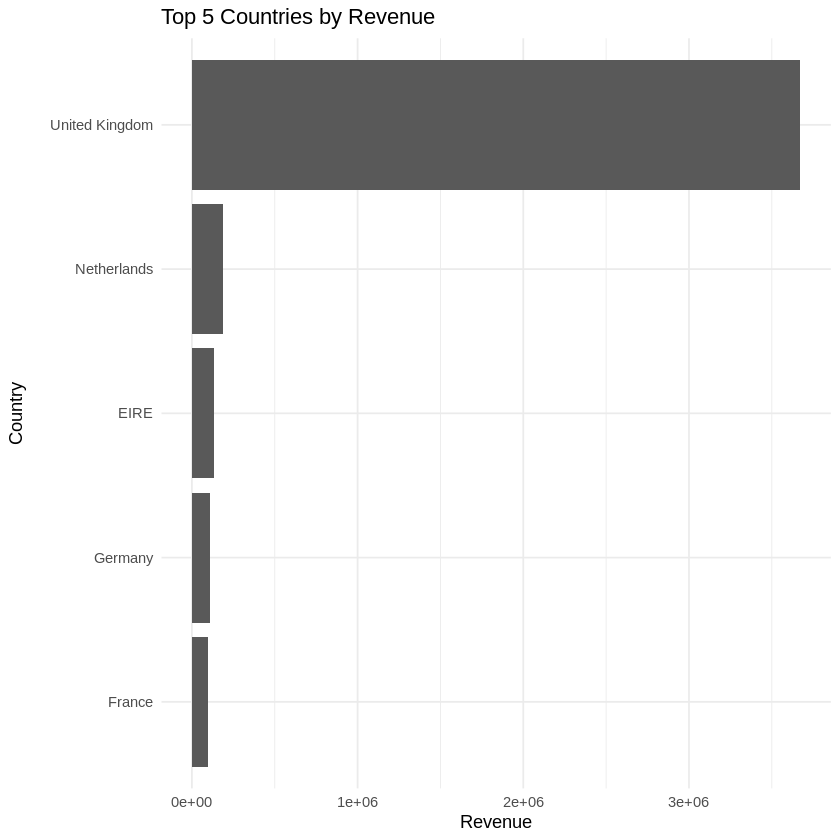

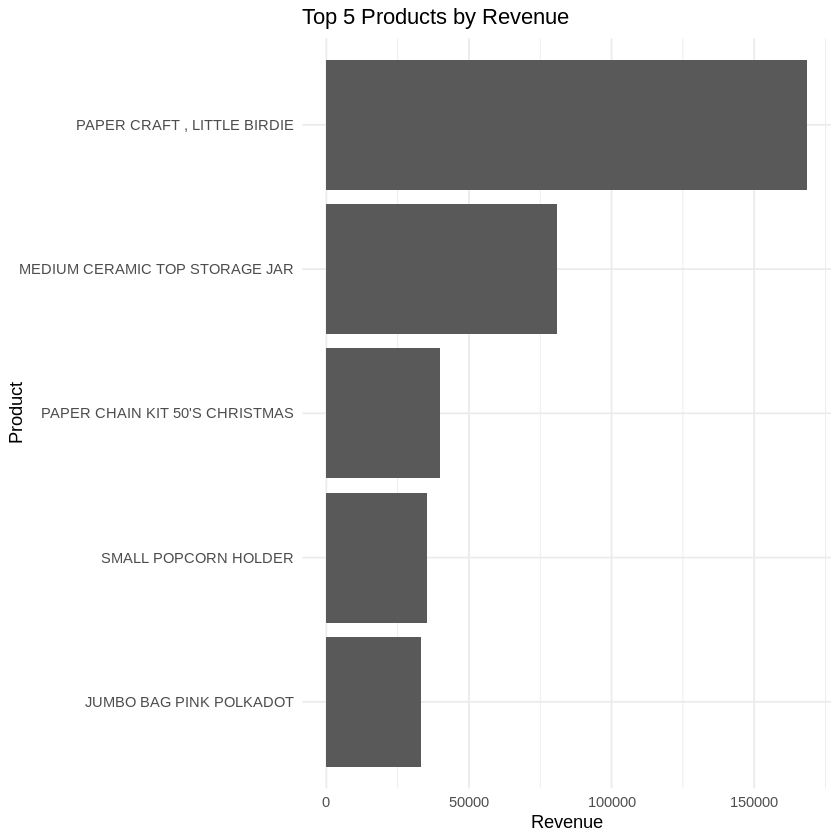

In [25]:
# Optional visualizations for the notebook

ggplot(top5_countries, aes(x = reorder(Country, Revenue), y = Revenue)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Countries by Revenue",
    x = "Country",
    y = "Revenue"
  ) +
  theme_minimal()

ggplot(top5_products, aes(x = reorder(Description, Revenue), y = Revenue)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Products by Revenue",
    x = "Product",
    y = "Revenue"
  ) +
  theme_minimal()


## Task 4 — Store and Retrieve Data Using SQLite

In [26]:
# Create SQLite database

db_path <- "/content/retail_sales.sqlite"

if (file.exists(db_path)) file.remove(db_path)

con <- dbConnect(SQLite(), db_path)

dbWriteTable(
  con,
  "retail_sales",
  integrated_data,
  overwrite = TRUE
)

cat("Tables in database:\n")
print(dbListTables(con))

cat("\nNumber of rows stored:\n")
print(dbGetQuery(con, "SELECT COUNT(*) AS rows_stored FROM retail_sales"))


Tables in database:
[1] "retail_sales"

Number of rows stored:
  rows_stored
1      260297


In [27]:
# SQL Query 1: Top 5 customers by revenue

sql_top_customers <- dbGetQuery(
  con,
  "
  SELECT
      CustomerID,
      Country,
      ROUND(SUM(Revenue), 2) AS Total_Revenue
  FROM retail_sales
  GROUP BY CustomerID, Country
  ORDER BY Total_Revenue DESC
  LIMIT 5;
  "
)

print(sql_top_customers)


  CustomerID        Country Total_Revenue
1      14646    Netherlands     186976.30
2      16446 United Kingdom     168472.11
3      18102 United Kingdom     159304.10
4      12415      Australia      77577.78
5      12346 United Kingdom      77183.60


In [28]:
# SQL Query 2: Total revenue by country

sql_country_revenue <- dbGetQuery(
  con,
  "
  SELECT
      Country,
      ROUND(SUM(Revenue), 2) AS Total_Revenue
  FROM retail_sales
  GROUP BY Country
  ORDER BY Total_Revenue DESC;
  "
)

print(head(sql_country_revenue, 10))


          Country Total_Revenue
1  United Kingdom    3672777.56
2     Netherlands     189664.82
3            EIRE     132417.75
4         Germany     110759.73
5          France      99592.68
6       Australia      85062.40
7     Switzerland      30348.71
8           Spain      27207.44
9          Sweden      20867.54
10          Japan      20757.26


In [29]:
# Verify that R and SQL give the same total revenue

sql_total <- dbGetQuery(
  con,
  "SELECT ROUND(SUM(Revenue), 2) AS Total_Revenue FROM retail_sales"
)

print(sql_total)
print(total_revenue)


  Total_Revenue
1       4513871
# A tibble: 1 × 1
  Total_Revenue
          <dbl>
1      4513871.


In [30]:
# Close database connection

dbDisconnect(con)

cat("SQLite database saved at:", db_path, "\n")


SQLite database saved at: /content/retail_sales.sqlite 


## Final Business Insights


In [31]:
# Automatically generate three business insights

top_country <- top5_countries %>% slice_head(n = 1)
second_country <- top5_countries %>% slice_tail(n = 1)
top_product <- top5_products %>% slice_head(n = 1)
top_customer <- top5_customers %>% slice_head(n = 1)

cat("BUSINESS INSIGHT 1 — Market performance\n")
cat(
  top_country$Country, "is the highest-revenue market with revenue of",
  round(top_country$Revenue, 2), ".\n\n"
)

cat("BUSINESS INSIGHT 2 — Product performance\n")
cat(
  "The highest-revenue product is", top_product$Description,
  "(", top_product$StockCode, ") with revenue of",
  round(top_product$Revenue, 2), ".\n\n"
)

cat("BUSINESS INSIGHT 3 — Customer value\n")
cat(
  "Customer", top_customer$CustomerID,
  "has the highest total purchase value of",
  round(top_customer$Purchase_Value, 2),
  "and represents an important high-value customer segment.\n"
)


BUSINESS INSIGHT 1 — Market performance
United Kingdom is the highest-revenue market with revenue of 3672778 .

BUSINESS INSIGHT 2 — Product performance
The highest-revenue product is PAPER CRAFT , LITTLE BIRDIE ( 23843 ) with revenue of 168469.6 .

BUSINESS INSIGHT 3 — Customer value
Customer 14646 has the highest total purchase value of 186976.3 and represents an important high-value customer segment.


In [32]:
# Export final integrated data for submission

write_csv(integrated_data, "/content/final_integrated_retail_sales.csv")

cat("Files available for download from Colab Files panel:\n")
print(c(
  "/content/retail_sources/transactions.csv",
  "/content/retail_sources/products.json",
  "/content/retail_sources/customers.xlsx",
  "/content/final_integrated_retail_sales.csv",
  "/content/retail_sales.sqlite"
))


Files available for download from Colab Files panel:
[1] "/content/retail_sources/transactions.csv"  
[2] "/content/retail_sources/products.json"     
[3] "/content/retail_sources/customers.xlsx"    
[4] "/content/final_integrated_retail_sales.csv"
[5] "/content/retail_sales.sqlite"              
